# Financial Fraud Detection & Risk Intelligence System

## 03 — Feature Engineering

### Objective

Create meaningful, reproducible, and leakage-aware
features for financial fraud detection.

### Primary Dataset

Financial Fraud Detection Dataset

### Target Variable

Fraudulent

- 0 = Non-fraud
- 1 = Fraud

In [12]:
import pandas as pd
import numpy as np

In [13]:
# Load raw dataset
df = pd.read_csv("../data/raw/financial_fraud_detection_dataset.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

Dataset loaded successfully
Dataset shape: (5000, 14)


In [14]:
# Create a separate DataFrame for feature engineering
df_fe = df.copy()

print("Feature engineering DataFrame shape:", df_fe.shape)

Feature engineering DataFrame shape: (5000, 14)


In [15]:
# Convert Transaction_Date into datetime format

df_fe["Transaction_Date"] = pd.to_datetime(df_fe["Transaction_Date"],
    format="%d-%m-%Y %H:%M", errors="coerce")

print("Invalid dates:", df_fe["Transaction_Date"].isna().sum())
print("Data type:", df_fe["Transaction_Date"].dtype)

Invalid dates: 0
Data type: datetime64[us]


In [16]:
# Create time-based features

df_fe["Transaction_Hour"] = (df_fe["Transaction_Date"].dt.hour)
df_fe["Transaction_DayOfWeek"] = (df_fe["Transaction_Date"].dt.dayofweek)
df_fe["Transaction_Month"] = (df_fe["Transaction_Date"].dt.month)
df_fe["Transaction_Day"] = (df_fe["Transaction_Date"].dt.day)
df_fe["Is_Weekend"] = (df_fe["Transaction_DayOfWeek"] >= 5).astype(int)
# This identifies: 5 → Saturday, 6 → Sunday, convert the Boolean result to integers:
#0 → Not a weekend 1 → Weekend

print("Time-based features created successfully")

Time-based features created successfully


In [17]:
# Inspect the time-based features

time_features = ["Transaction_Date", "Transaction_Hour", "Transaction_DayOfWeek",
    "Transaction_Month", "Transaction_Day", "Is_Weekend"]

print(df_fe[time_features].head(10))

     Transaction_Date  Transaction_Hour  Transaction_DayOfWeek  \
0 2023-10-04 07:45:00                 7                      2   
1 2023-09-26 08:29:00                 8                      1   
2 2023-07-18 15:54:00                15                      1   
3 2023-10-16 17:10:00                17                      0   
4 2023-09-09 00:46:00                 0                      5   
5 2024-01-14 03:15:00                 3                      6   
6 2023-02-09 08:56:00                 8                      3   
7 2023-03-26 13:12:00                13                      6   
8 2023-03-06 20:09:00                20                      0   
9 2023-06-27 12:06:00                12                      1   

   Transaction_Month  Transaction_Day  Is_Weekend  
0                 10                4           0  
1                  9               26           0  
2                  7               18           0  
3                 10               16           0  
4            

In [18]:
# Check feature ranges

print("\nHour range:")
print(df_fe["Transaction_Hour"].min(), df_fe["Transaction_Hour"].max())

print("\nDay of week range:")
print(df_fe["Transaction_DayOfWeek"].min(), df_fe["Transaction_DayOfWeek"].max())

print("\nMonth range:")
print(df_fe["Transaction_Month"].min(), df_fe["Transaction_Month"].max())

print("\nWeekend values:")
print(df_fe["Is_Weekend"].unique())


Hour range:
0 23

Day of week range:
0 6

Month range:
1 12

Weekend values:
[0 1]


In [19]:
# Validate DataFrame after feature creation

print("Shape after feature engineering:", df_fe.shape)

print("\nMissing values in new features:")
print(df_fe[time_features].isnull().sum())

Shape after feature engineering: (5000, 19)

Missing values in new features:
Transaction_Date         0
Transaction_Hour         0
Transaction_DayOfWeek    0
Transaction_Month        0
Transaction_Day          0
Is_Weekend               0
dtype: int64


In [20]:
# Create transaction amount ratio
df_fe["Amount_to_Average_Ratio"]=(df_fe["Transaction_Amount"]/df_fe["Average_Spend"])
print("Amount-to-average ratio created successfully")

Amount-to-average ratio created successfully


In [21]:
# Inspect the new feature
print(df_fe[["Transaction_Amount","Average_Spend","Amount_to_Average_Ratio"]].head(10))

   Transaction_Amount  Average_Spend  Amount_to_Average_Ratio
0               37.54         417.40                 0.089938
1              240.81         335.47                 0.717829
2              105.34         432.03                 0.243826
3               73.04         488.30                 0.149580
4               13.57         437.03                 0.031050
5               13.57         207.80                 0.065303
6                4.79         409.11                 0.011708
7              160.90         358.71                 0.448552
8               73.53          40.19                 1.829560
9               98.50         465.58                 0.211564


In [22]:
# Validate amount ratio

print("Missing values:")
print(df_fe["Amount_to_Average_Ratio"].isna().sum())

print("\nInfinite values:")
print(np.isinf(df_fe["Amount_to_Average_Ratio"]).sum())

print("\nRatio summary:")
print(df_fe["Amount_to_Average_Ratio"].describe())

Missing values:
0

Infinite values:
0

Ratio summary:
count    5000.000000
mean        0.588936
std         1.285842
min         0.000000
25%         0.091337
50%         0.241066
75%         0.576681
max        28.363287
Name: Amount_to_Average_Ratio, dtype: float64


In [23]:
# Difference between transaction amount and average spend
df_fe["Amount_vs_Average_Difference"]=(df_fe["Transaction_Amount"]-df_fe["Average_Spend"])
print("Amount difference feature created successfully")

Amount difference feature created successfully


# Interpretation

Positive value → Transaction amount is greater than average spend.
Negative value → Transaction amount is lower than average spend.
Value near zero → Transaction amount is close to average spend.

In [24]:
# Validate amount-based features

amount_features = ["Transaction_Amount","Average_Spend","Amount_to_Average_Ratio",
                   "Amount_vs_Average_Difference"]
print(df_fe[amount_features].head(10))

print("\nMissing values:")
print(df_fe[amount_features].isna().sum())

   Transaction_Amount  Average_Spend  Amount_to_Average_Ratio  \
0               37.54         417.40                 0.089938   
1              240.81         335.47                 0.717829   
2              105.34         432.03                 0.243826   
3               73.04         488.30                 0.149580   
4               13.57         437.03                 0.031050   
5               13.57         207.80                 0.065303   
6                4.79         409.11                 0.011708   
7              160.90         358.71                 0.448552   
8               73.53          40.19                 1.829560   
9               98.50         465.58                 0.211564   

   Amount_vs_Average_Difference  
0                       -379.86  
1                        -94.66  
2                       -326.69  
3                       -415.26  
4                       -423.46  
5                       -194.23  
6                       -404.32  
7           

In [25]:
# Validate the amount ratio 
print("Infinite values:")
print(np.isinf(df_fe["Amount_to_Average_Ratio"]).sum())

print("\nRatio summary:")
print(df_fe["Amount_to_Average_Ratio"].describe())

print("\nDifference summary:")
print(df_fe["Amount_vs_Average_Difference"].describe())

Infinite values:
0

Ratio summary:
count    5000.000000
mean        0.588936
std         1.285842
min         0.000000
25%         0.091337
50%         0.241066
75%         0.576681
max        28.363287
Name: Amount_to_Average_Ratio, dtype: float64

Difference summary:
count    5000.000000
mean     -179.196468
std       159.177124
min      -497.680000
25%      -306.347500
50%      -181.525000
75%       -56.425000
max       501.520000
Name: Amount_vs_Average_Difference, dtype: float64


In [26]:
# Inspect Previous_Transactions

print(df_fe["Previous_Transactions"].describe())

print("\nUnique values:")
print(df_fe["Previous_Transactions"].nunique())

print("\nFirst 10 values:")
print(df_fe["Previous_Transactions"].head(10))

count    5000.000000
mean       99.414000
std        57.022968
min         1.000000
25%        50.000000
50%       100.000000
75%       148.000000
max       199.000000
Name: Previous_Transactions, dtype: float64

Unique values:
199

First 10 values:
0     94
1     76
2     60
3     68
4     57
5     64
6    182
7     80
8     87
9    182
Name: Previous_Transactions, dtype: int64


In [27]:
# Fraud rate by Previous_Transactions
previous_transactions_analysis = (df_fe.groupby("Previous_Transactions")["Fraudulent"]
    .agg(Transaction_Count="count", Fraud_Count="sum", Fraud_Rate="mean").reset_index())

# Convert fraud rate to percentage
previous_transactions_analysis["Fraud_Rate"] = (previous_transactions_analysis["Fraud_Rate"] * 100)

print(previous_transactions_analysis.head(10))
print("\nSummary:")
print(previous_transactions_analysis["Fraud_Rate"].describe())

   Previous_Transactions  Transaction_Count  Fraud_Count  Fraud_Rate
0                      1                 20            1    5.000000
1                      2                 22            1    4.545455
2                      3                 28            1    3.571429
3                      4                 29            6   20.689655
4                      5                 29            2    6.896552
5                      6                 24            3   12.500000
6                      7                 27            5   18.518519
7                      8                 22            6   27.272727
8                      9                 28            3   10.714286
9                     10                 25            2    8.000000

Summary:
count    199.000000
mean       9.548493
std        6.346225
min        0.000000
25%        4.545455
50%        9.090909
75%       13.714734
max       27.272727
Name: Fraud_Rate, dtype: float64


In [28]:
# Create broad Previous_Transactions bands
df_fe["Previous_Transactions_Band"] = pd.cut(df_fe["Previous_Transactions"],
    bins=[0, 25, 50, 100, 150, 200],
    labels=["1-25","26-50","51-100","101-150","151-200"],include_lowest=True)

print("Previous transaction bands created successfully")
print(df_fe["Previous_Transactions_Band"].value_counts().sort_index())

Previous transaction bands created successfully
Previous_Transactions_Band
1-25        621
26-50       642
51-100     1251
101-150    1295
151-200    1191
Name: count, dtype: int64


In [29]:
# Fraud rate by Previous_Transactions_Band

previous_band_analysis = (
    df_fe.groupby("Previous_Transactions_Band",observed=False)["Fraudulent"]
    .agg(Transaction_Count="count", Fraud_Count="sum", Fraud_Rate="mean").reset_index())

# Convert fraud rate to percentage
previous_band_analysis["Fraud_Rate"] = (previous_band_analysis["Fraud_Rate"] * 100)

print(previous_band_analysis)

  Previous_Transactions_Band  Transaction_Count  Fraud_Count  Fraud_Rate
0                       1-25                621           73   11.755233
1                      26-50                642           57    8.878505
2                     51-100               1251          119    9.512390
3                    101-150               1295          120    9.266409
4                    151-200               1191          113    9.487825


In [30]:
# Create an exploratory high-spend flag

df_fe["Amount_Above_Average_Flag"] = (df_fe["Amount_to_Average_Ratio"] > 1).astype(int)

print("Amount_Above_Average_Flag created successfully")
print(df_fe["Amount_Above_Average_Flag"].value_counts().sort_index())

Amount_Above_Average_Flag created successfully
Amount_Above_Average_Flag
0    4328
1     672
Name: count, dtype: int64


In [31]:
# Fraud rate by Amount_Above_Average_Flag
amount_flag_analysis = (df_fe.groupby("Amount_Above_Average_Flag")["Fraudulent"]
    .agg(Transaction_Count="count",Fraud_Count="sum",Fraud_Rate="mean").reset_index())

# Convert fraud rate to percentage
amount_flag_analysis["Fraud_Rate"] = (amount_flag_analysis["Fraud_Rate"] * 100)

print(amount_flag_analysis)

   Amount_Above_Average_Flag  Transaction_Count  Fraud_Count  Fraud_Rate
0                          0               4328          418    9.658041
1                          1                672           64    9.523810


In [32]:
# Review current feature-engineering DataFrame

print("DataFrame shape:", df_fe.shape)

print("\nColumns:")
print(df_fe.columns.tolist())

print("\nData types:")
print(df_fe.dtypes)

DataFrame shape: (5000, 23)

Columns:
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Suspicious_Keyword', 'Fraudulent', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_Month', 'Transaction_Day', 'Is_Weekend', 'Amount_to_Average_Ratio', 'Amount_vs_Average_Difference', 'Previous_Transactions_Band', 'Amount_Above_Average_Flag']

Data types:
Transaction_ID                             str
Customer_ID                                str
Transaction_Date                datetime64[us]
Transaction_Amount                     float64
Merchant_Category                          str
Payment_Method                             str
Device_Type                                str
Location                                   str
Is_International                         int64
Previous_Transactions                    int64
Av

In [33]:
# Review categorical feature values

categorical_columns = ["Merchant_Category","Payment_Method","Device_Type","Location","Is_International","Suspicious_Keyword"]

for column in categorical_columns:
    print(f"\n{column}")
    print("Unique values:", df_fe[column].nunique())
    print(df_fe[column].unique())


Merchant_Category
Unique values: 8
<ArrowStringArray>
[       'Travel',     'Utilities', 'Entertainment',        'Health',
       'Fashion',       'Grocery',          'Food',   'Electronics']
Length: 8, dtype: str

Payment_Method
Unique values: 5
<ArrowStringArray>
['PayPal', 'Debit Card', 'NetBanking', 'Credit Card', 'UPI']
Length: 5, dtype: str

Device_Type
Unique values: 3
<ArrowStringArray>
['POS', 'Mobile', 'Desktop']
Length: 3, dtype: str

Location
Unique values: 7
<ArrowStringArray>
['Bengaluru', 'Kolkata', 'Mumbai', 'Delhi', 'Chennai', 'Pune', 'Hyderabad']
Length: 7, dtype: str

Is_International
Unique values: 2
[0 1]

Suspicious_Keyword
Unique values: 2
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [34]:
# Feature audit table
feature_audit = pd.DataFrame({"Feature": df_fe.columns,"Data_Type":df_fe.dtypes.astype(str).values})

# Display the audit table
print(feature_audit.to_string(index=False))

                     Feature      Data_Type
              Transaction_ID            str
                 Customer_ID            str
            Transaction_Date datetime64[us]
          Transaction_Amount        float64
           Merchant_Category            str
              Payment_Method            str
                 Device_Type            str
                    Location            str
            Is_International          int64
       Previous_Transactions          int64
               Average_Spend        float64
            Account_Age_Days          int64
          Suspicious_Keyword            str
                  Fraudulent          int64
            Transaction_Hour          int32
       Transaction_DayOfWeek          int32
           Transaction_Month          int32
             Transaction_Day          int32
                  Is_Weekend          int64
     Amount_to_Average_Ratio        float64
Amount_vs_Average_Difference        float64
  Previous_Transactions_Band    

In [35]:
# Check missing values across all features
missing_summary = (df_fe.isnull().sum().reset_index())
missing_summary.columns = ["Feature", "Missing_Count"]

print(missing_summary[missing_summary["Missing_Count"] > 0])

Empty DataFrame
Columns: [Feature, Missing_Count]
Index: []


In [36]:
# Inspect highest amount-to-average ratios

top_ratio_values = (df_fe[["Transaction_ID","Transaction_Amount",
                           "Average_Spend","Amount_to_Average_Ratio","Fraudulent"]]
    .sort_values(by="Amount_to_Average_Ratio",ascending=False).head(10))

print(top_ratio_values.to_string(index=False))

Transaction_ID  Transaction_Amount  Average_Spend  Amount_to_Average_Ratio  Fraudulent
       T103714              369.29          13.02                28.363287           0
       T104445              306.14          14.38                21.289291           0
       T104765              387.63          19.31                20.074055           1
       T103431              374.04          19.74                18.948328           0
       T102717              292.57          17.06                17.149472           0
       T101544              263.59          15.65                16.842812           0
       T103067              268.23          16.80                15.966071           0
       T102304              214.77          15.73                13.653528           1
       T100401              186.28          14.42                12.918169           0
       T101209              468.12          37.06                12.631409           0


In [37]:
# Inspect transactions with the lowest Average_Spend

low_average_spend = (
    df_fe[["Transaction_ID","Transaction_Amount","Average_Spend","Amount_to_Average_Ratio","Fraudulent"]]
    .sort_values(by="Average_Spend",ascending=True).head(10))

print(low_average_spend.to_string(index=False))

Transaction_ID  Transaction_Amount  Average_Spend  Amount_to_Average_Ratio  Fraudulent
       T100866               13.50          10.01                 1.348651           0
       T100764                2.73          10.33                 0.264279           0
       T100830               20.35          10.42                 1.952975           1
       T104938              114.90          10.45                10.995215           0
       T102463               67.40          10.56                 6.382576           0
       T100354                5.85          10.58                 0.552930           0
       T102900               10.95          10.76                 1.017658           0
       T104459               63.63          10.79                 5.897127           0
       T102464               77.55          10.93                 7.095151           1
       T103543               33.56          10.97                 3.059253           0


In [38]:
import numpy as np

df_fe["Log_Amount_to_Average_Ratio"] = np.log1p(df_fe["Amount_to_Average_Ratio"])
df_fe[["Transaction_ID","Amount_to_Average_Ratio","Log_Amount_to_Average_Ratio","Fraudulent"]].head(10)

,Transaction_ID,Amount_to_Average_Ratio,Log_Amount_to_Average_Ratio,Fraudulent
0,T100000,0.089938,0.086121,0
1,T100001,0.717829,0.541061,0
2,T100002,0.243826,0.218192,0
3,T100003,0.149580,0.139397,0
4,T100004,0.031050,0.030578,0
5,T100005,0.065303,0.063259,0
6,T100006,0.011708,0.011640,0
7,T100007,0.448552,0.370564,0
8,T100008,1.829560,1.040121,0
9,T100009,0.211564,0.191912,0


In [39]:
df_fe["Log_Amount_to_Average_Ratio"].describe()

count    5000.000000
mean        0.347588
std         0.397345
min         0.000000
25%         0.087404
50%         0.215971
75%         0.455322
max         3.379745
Name: Log_Amount_to_Average_Ratio, dtype: float64

In [40]:
print("Missing values:",df_fe["Log_Amount_to_Average_Ratio"].isna().sum())
print("Infinite values:",np.isinf(df_fe["Log_Amount_to_Average_Ratio"]).sum())

Missing values: 0
Infinite values: 0


In [41]:
# Display all feature columns
for i, column in enumerate(df_fe.columns, start=1):
    print(i, column)

1 Transaction_ID
2 Customer_ID
3 Transaction_Date
4 Transaction_Amount
5 Merchant_Category
6 Payment_Method
7 Device_Type
8 Location
9 Is_International
10 Previous_Transactions
11 Average_Spend
12 Account_Age_Days
13 Suspicious_Keyword
14 Fraudulent
15 Transaction_Hour
16 Transaction_DayOfWeek
17 Transaction_Month
18 Transaction_Day
19 Is_Weekend
20 Amount_to_Average_Ratio
21 Amount_vs_Average_Difference
22 Previous_Transactions_Band
23 Amount_Above_Average_Flag
24 Log_Amount_to_Average_Ratio


In [42]:
# Check dataset shape
print("Dataset shape:", df_fe.shape)

# Check duplicate rows
print("Duplicate rows:", df_fe.duplicated().sum())

# Check missing values
print("\nMissing values:")
print(df_fe.isna().sum()[df_fe.isna().sum() > 0])

# Check target distribution
print("\nTarget distribution:")
print(df_fe["Fraudulent"].value_counts())

print("\nTarget percentage:")
print(df_fe["Fraudulent"].value_counts(normalize=True).mul(100).round(2))

Dataset shape: (5000, 24)
Duplicate rows: 0

Missing values:
Series([], dtype: int64)

Target distribution:
Fraudulent
0    4518
1     482
Name: count, dtype: int64

Target percentage:
Fraudulent
0    90.36
1     9.64
Name: proportion, dtype: float64


# Train/Test Strategy + Baseline Model work follows order:

1. Create the train/test split.
2. Build the preprocessing pipeline.
3. Train Logistic Regression.
4. Evaluate the baseline.
5. Train Decision Tree, Random Forest, and XGBoost afterward.

In [43]:
# Separate target variable
y = df_fe["Fraudulent"]

# Features for the initial model
feature_columns = [
    "Transaction_Amount",
    "Merchant_Category",
    "Payment_Method",
    "Device_Type",
    "Location",
    "Is_International",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days",
    "Transaction_Hour",
    "Transaction_DayOfWeek",
    "Transaction_Month",
    "Transaction_Day",
    "Is_Weekend",
    "Amount_to_Average_Ratio",
    "Amount_vs_Average_Difference",
    "Previous_Transactions_Band",
    "Log_Amount_to_Average_Ratio"]

X = df_fe[feature_columns].copy()

print("Feature dataset shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Feature dataset shape: (5000, 18)
Target shape: (5000,)

Feature columns:
['Transaction_Amount', 'Merchant_Category', 'Payment_Method', 'Device_Type', 'Location', 'Is_International', 'Previous_Transactions', 'Average_Spend', 'Account_Age_Days', 'Transaction_Hour', 'Transaction_DayOfWeek', 'Transaction_Month', 'Transaction_Day', 'Is_Weekend', 'Amount_to_Average_Ratio', 'Amount_vs_Average_Difference', 'Previous_Transactions_Band', 'Log_Amount_to_Average_Ratio']


In [44]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Display the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4000, 18)
X_test shape: (1000, 18)
y_train shape: (4000,)
y_test shape: (1000,)


In [45]:
print("Training target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTesting target percentage:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training target distribution:
Fraudulent
0    3614
1     386
Name: count, dtype: int64

Training target percentage:
Fraudulent
0    90.35
1     9.65
Name: proportion, dtype: float64

Testing target distribution:
Fraudulent
0    904
1     96
Name: count, dtype: int64

Testing target percentage:
Fraudulent
0    90.4
1     9.6
Name: proportion, dtype: float64


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numeric features
numeric_features = [
    "Transaction_Amount",
    "Is_International",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days",
    "Transaction_Hour",
    "Transaction_DayOfWeek",
    "Transaction_Month",
    "Transaction_Day",
    "Is_Weekend",
    "Amount_to_Average_Ratio",
    "Amount_vs_Average_Difference",
    "Log_Amount_to_Average_Ratio"
]

# Categorical features
categorical_features = ["Merchant_Category","Payment_Method","Device_Type","Location","Previous_Transactions_Band"]

# Preprocessing transformer
preprocessor = ColumnTransformer(transformers=[("num", StandardScaler(), numeric_features),
                  ("cat",OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical_features)])

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [47]:
#Create the Logistic Regression Pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [48]:
# Create Logistic Regression baseline pipeline
logistic_pipeline = Pipeline(steps=[("preprocessor", preprocessor),
        ("classifier",LogisticRegression(max_iter=1000,random_state=42))])
print("Logistic Regression pipeline created successfully.")

Logistic Regression pipeline created successfully.


# What does this code do?

Component.            Purpose
Pipeline              Connects preprocessing and model training
preprocessor          Scales numerical features and encodes categorical features
LogisticRegression    Establishes our baseline classifier
max_iter=1000         Allows additional iterations for convergence
random_state=42       Reproducibility where applicable

In [49]:
# Train the Logistic Regression model
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [50]:
# Predict class labels
y_pred = logistic_pipeline.predict(X_test)

# Predict fraud probabilities
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("\nPredicted classes:")
print(y_pred[:10])

print("\nFraud probabilities:")
print(y_proba[:10])

Predictions generated successfully.

Predicted classes:
[0 0 0 0 0 0 0 0 0 0]

Fraud probabilities:
[0.14319726 0.09003243 0.03335306 0.01223235 0.00971553 0.01146357
 0.12977037 0.19457263 0.08483205 0.01026989]


In [51]:
#Evaluate the Baseline Model
from sklearn.metrics import (confusion_matrix,
                             classification_report,
                             roc_auc_score,
                             precision_score,
                             recall_score,
                             f1_score)

In [52]:
# Calculate classification metrics
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("Logistic Regression Baseline Results")
print("--------------------------------------")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Logistic Regression Baseline Results
--------------------------------------
Precision: 0.3571
Recall:    0.1042
F1-Score:  0.1613
ROC-AUC:   0.7454


What these metrics mean

Metric     Meaning
Precision  Of the transactions predicted as fraud, how many were actually fraud?
Recall.    Of all actual fraud transactions, how many did the model detect?
F1-score   Balance between precision and recall
ROC-AUC    Measures ranking ability across classification thresholds

In [53]:
#Display the confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[886  18]
 [ 86  10]]


                   Predicted Non-Fraud               Predicted Fraud
Actual Non-Fraud       TN                             FP
Actual Fraud           FN                             TP
TN: Correctly identified non-fraud transactions.
FP: Legitimate/Non-fraud transactions transactions incorrectly flagged.
FN: Fraudulent transactions missed by model
TP: Correctly identified fraud transactions.

In [54]:
#Display the complete classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       904
           1       0.36      0.10      0.16        96

    accuracy                           0.90      1000
   macro avg       0.63      0.54      0.55      1000
weighted avg       0.86      0.90      0.87      1000



The baseline identifies non-fraudulent transactions much more effectively than fraudulent transactions. Fraud recall is only 10%, meaning many actual fraud cases are being missed at the current classification threshold.

Precision: 0.36 Of the transactions predicted as fraud, approximately 36% were actually fraudulent. The remaining flagged transactions were false positives.

Recall: 0.10, The test set contains 96 actual fraudulent transactions. A recall of 0.10 means the model detected approximately 10% of them at the current threshold. This indicates that the baseline is missing many fraud cases.

F1-score: 0.16, The F1-score combines precision and recall. Because fraud recall is low, the fraud-class F1-score is also low.

Baseline is a reference point, not an acceptable final fraud-detection system yet. We need to investigate whether other models and decision thresholds can improve fraud detection.

In [55]:
#Inspect the confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[886  18]
 [ 86  10]]


In [56]:
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7454023783185841


In [57]:
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Precision: 0.3571
Recall:    0.1042
F1-Score:  0.1613
ROC-AUC:   0.7454


## Logistic Regression Baseline Results

- Test samples: 1,000
- Accuracy: 89.60%
- Fraud Precision: 35.71%
- Fraud Recall: 10.42%
- Fraud F1-score: 16.13%
- ROC-AUC: 0.7454

### Interpretation

The baseline model performs substantially better on the
non-fraud class than on the fraud class at the default
classification threshold.

It detects 10 out of 96 fraudulent transactions and misses
86 fraudulent transactions. Therefore, further model
experimentation and threshold analysis are required.

The baseline is retained as a reference for comparison
with Decision Tree, Random Forest, and XGBoost.

In [58]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

# Create Decision Tree pipeline
decision_tree_pipeline = Pipeline(
steps=[("preprocessor", preprocessor),
       ("classifier", DecisionTreeClassifier(max_depth=5,
                                             min_samples_split=10,
                                             min_samples_leaf=5,
                                             class_weight="balanced",
                                             random_state=42))])

print("Decision Tree pipeline created successfully.")

Decision Tree pipeline created successfully.


In [59]:
# Train the Decision Tree model
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [60]:
# Generate predictions
dt_y_pred = decision_tree_pipeline.predict(X_test)

# Generate fraud probabilities
dt_y_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print("First 10 predictions:", dt_y_pred[:10])
print("First 10 fraud probabilities:", dt_y_prob[:10])

Predictions generated successfully.
First 10 predictions: [1 0 0 0 0 0 1 1 0 0]
First 10 fraud probabilities: [0.78845771 0.14767387 0.14767387 0.14767387 0.14767387 0.14767387
 0.70700826 0.84252244 0.18750093 0.18750093]


Code                              Purpose
predict(X_test).              Predicts whether each transaction is fraud or non-fraud
predict_proba(X_test)[:, 1]   Retrieves the predicted probability of fraud
dt_y_pred                     Stores the predicted classes
dt_y_prob                     Stores the fraud probabilities for next evaluation

In [61]:
#Evaluate the Decision Tree
from sklearn.metrics import classification_report

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, dt_y_pred))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.74      0.83       904
           1       0.22      0.70      0.33        96

    accuracy                           0.73      1000
   macro avg       0.59      0.72      0.58      1000
weighted avg       0.89      0.73      0.79      1000



Metric          Why it matters
Precision       How many transactions predicted as fraud are actually fraudulent
Recall.         How many actual fraudulent transactions are detected
F1-score        Balance between precision and recall
Support         Number of actual samples in each class

In [62]:
#Inspect the Decision Tree confusion matrix
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, dt_y_pred)

print("Decision Tree Confusion Matrix:")
print(dt_cm)

Decision Tree Confusion Matrix:
[[666 238]
 [ 29  67]]


                   Predicted Non-Fraud               Predicted Fraud
Actual Non-Fraud       TN                             FP
Actual Fraud           FN                             TP
TN: Correctly identified non-fraud transactions.
FP: Legitimate/Non-fraud transactions transactions incorrectly flagged.
FN: Fraudulent transactions missed by model
TP: Correctly identified fraud transactions.

In [63]:
# Calculate Decision Tree ROC-AUC using fraud probabilities
from sklearn.metrics import roc_auc_score

dt_roc_auc = roc_auc_score(y_test, dt_y_prob)

print(f"Decision Tree ROC-AUC: {dt_roc_auc:.4f}")

Decision Tree ROC-AUC: 0.6784


Why use dt_y_prob?

ROC-AUC evaluates the model's ability to distinguish between fraudulent and non-fraudulent transactions using its probability scores across different classification thresholds.

Metric                 Logistic Regression        Decision Tree

Accuracy               89.60%                     73.30%
Fraud Precision        35.71%                     21.97%
Fraud Recall           10.42%                     69.79%
Fraud F1-score         16.13%                     33.33%
ROC-AUC                0.7454                     0.6784
False Negatives        86                         29
False Positives        18                         238

conclusion: Neither model should be selected as the final model yet. We need to test additional algorithms and later examine probability thresholds based on the business cost of missed fraud versus false alerts.

In [64]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[("preprocessor", preprocessor),
           ("classifier", RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1))])

print("Random Forest pipeline created successfully.")

Random Forest pipeline created successfully.


Parameter                    Purpose

n_estimators=200             Builds 200 decision trees
max_depth=8                  Limits the depth of each tree
min_samples_split=10         Requires at least 10 samples to split a node
min_samples_leaf=5           Keeps at least 5 samples in each leaf
class_weight="balanced"      Gives additional weight to the minority fraud class
random_state=42              Makes the experiment reproducible
n_jobs=-1                    Uses available CPU cores to speed up training

In [65]:
# Train the Random Forest model
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [66]:
# Generate predictions
rf_y_pred = random_forest_pipeline.predict(X_test)

# Generate fraud probabilities
rf_y_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")
print("First 10 predictions:", rf_y_pred[:10])
print("First 10 fraud probabilities:", rf_y_prob[:10])

Random Forest predictions generated successfully.
First 10 predictions: [1 0 0 0 0 0 1 1 0 0]
First 10 fraud probabilities: [0.60605388 0.22760798 0.22282909 0.20992267 0.24486043 0.24191486
 0.56935818 0.63541594 0.36476528 0.22291073]


Output       Purpose

rf_y_pred    Predicted class: non-fraud (0) or fraud (1)
rf_y_prob    Predicted probability of fraud
X_test       Ensures evaluation uses same test transactions as earlier models

In [67]:
#Evaluate the Random Forest
from sklearn.metrics import classification_report

print("Random Forest Classification Report:\n")
print(classification_report(y_test, rf_y_pred))

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.74      0.84       904
           1       0.23      0.73      0.35        96

    accuracy                           0.74      1000
   macro avg       0.60      0.74      0.60      1000
weighted avg       0.89      0.74      0.79      1000



In [68]:
## Generate the Confusion matrix
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_y_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[673 231]
 [ 26  70]]


In [69]:
# Calculate ROC-AUC using fraud probabilities
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")

Random Forest ROC-AUC: 0.7586


Evaluation and its Purpose

Classification report: Measures precision, recall, and F1-score at the current threshold.
Confusion matrix: Shows correct predictions, missed fraud, and false alerts.
ROC-AUC: Evaluates the model's ability to rank fraud cases above non-fraud cases using probability scores.

Model Evaluation

Metric           Logistic Regression       Decision Tree        Random Forest

Accuracy	          89.60%	            73.30%	              74.30%
Fraud Precision	      35.71%	            21.97%	              23.26%
Fraud Recall	      10.42%	            69.79%	              72.92%
Fraud F1-score	      16.13%	            33.33%	              34.99%
ROC-AUC	              0.7454                0.6784	              0.7586
False Negatives	        86               	  29	                26
False Positives	        18	                  238	                231

Random Forest currently has the highest ROC-AUC among the three tested models and slightly improves the fraud recall over the Decision Tree. However, this does not establish it as the final model. We still need to investigate validation stability, thresholds, and additional algorithms.

In [70]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Calculate the class imbalance weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Scale position weight: {scale_pos_weight:.4f}")

# Create the XGBoost pipeline
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("XGBoost pipeline created successfully.")

Scale position weight: 9.3627
XGBoost pipeline created successfully.


The calculated class weight is correct for your training data: scale_pos_weight= 386/3614≈9.3627

In [71]:
# Train the XGBoost model
xgboost_pipeline.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [72]:
# Generate predictions
xgb_y_pred = xgboost_pipeline.predict(X_test)

# Generate fraud probabilities
xgb_y_prob = xgboost_pipeline.predict_proba(X_test)[:, 1]

print("XGBoost predictions generated successfully.")
print("First 10 predictions:", xgb_y_pred[:10])
print("First 10 fraud probabilities:", xgb_y_prob[:10])

XGBoost predictions generated successfully.
First 10 predictions: [1 0 0 0 0 0 1 1 0 0]
First 10 fraud probabilities: [0.6448092  0.05141322 0.09826519 0.05272876 0.09772743 0.1699475
 0.5380198  0.8097805  0.14393955 0.05272055]


Variable      Purpose
xgb_y_pred    Predicted class: 0 or 1
xgb_y_prob    Predicted probability of fraud
X_test        Same test set used for the previous models

In [73]:
#Classification report
from sklearn.metrics import classification_report

print("XGBoost Classification Report:\n")
print(classification_report(y_test, xgb_y_pred))

XGBoost Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.78      0.86       904
           1       0.22      0.60      0.33        96

    accuracy                           0.76      1000
   macro avg       0.59      0.69      0.59      1000
weighted avg       0.88      0.76      0.80      1000



In [74]:
# Generate the confusion matrix
from sklearn.metrics import confusion_matrix

xgb_cm = confusion_matrix(y_test, xgb_y_pred)

print("XGBoost Confusion Matrix:")
print(xgb_cm)

XGBoost Confusion Matrix:
[[704 200]
 [ 38  58]]


                   Predicted Non-Fraud               Predicted Fraud
Actual Non-Fraud       TN                             FP
Actual Fraud           FN                             TP
TN: Correctly identified non-fraud transactions.
FP: Legitimate/Non-fraud transactions transactions incorrectly flagged.
FN: Fraudulent transactions missed by model
TP: Correctly identified fraud transactions.

The model detected 58 of the 96 fraudulent transactions.
It missed 38 fraudulent transactions.
It incorrectly flagged 200 legitimate transactions.
Fraud recall is approximately 60.42% (58 / 96).
Fraud precision is approximately 22.48% (58 / 258).

In [75]:
# Calculate ROC-AUC using fraud probabilities
from sklearn.metrics import roc_auc_score

xgb_roc_auc = roc_auc_score(y_test, xgb_y_prob)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")

XGBoost ROC-AUC: 0.7561


In [76]:
# Import pandas for creating the model comparison table
import pandas as pd

# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)

# Store the prediction results from each trained model
models = { "Logistic Regression": (y_pred, y_proba), "Decision Tree": (dt_y_pred, dt_y_prob),
    "Random Forest": (rf_y_pred, rf_y_prob), "XGBoost": (xgb_y_pred, xgb_y_prob)}

# Create an empty list to store calculated model results
comparison_results = []

# Calculate the evaluation metrics for every model
for model_name, (predictions, probabilities) in models.items():

    # Calculate the confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()

    # Calculate performance metrics from the actual predictions
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, zero_division=0)
    recall = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    roc_auc = roc_auc_score(y_test, probabilities)

    # Store the calculated results
    comparison_results.append({
        "Model": model_name, "Accuracy": accuracy * 100, "Fraud Precision": precision * 100, "Fraud Recall": recall * 100,
        "Fraud F1": f1 * 100, "ROC-AUC": roc_auc * 100, "False Positives": fp, "False Negatives": fn})

# Convert the results into a DataFrame
model_comparison_df = pd.DataFrame(comparison_results)

# Format percentage-based metrics
percentage_columns = ["Accuracy", "Fraud Precision", "Fraud Recall", "Fraud F1", "ROC-AUC"]

for column in percentage_columns:
    model_comparison_df[column] = model_comparison_df[column].map(lambda x: f"{x:.2f}%")

# Display the final comparison table
display(model_comparison_df)

,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,ROC-AUC,False Positives,False Negatives
0,Logistic Regression,89.60%,35.71%,10.42%,16.13%,74.54%,18,86
1,Decision Tree,73.30%,21.97%,69.79%,33.42%,67.84%,238,29
2,Random Forest,74.30%,23.26%,72.92%,35.26%,75.86%,231,26
3,XGBoost,76.20%,22.48%,60.42%,32.77%,75.61%,200,38


## Four-model comparison

Metric           Logistic Regression       Decision Tree        Random Forest        XGBoost

Accuracy	          89.60%	            73.30%	              74.30%	          76.20%
Fraud Precision	      35.71%	            21.97%	              23.26%              22.48%
Fraud Recall	      10.42%	            69.79%	              72.92%              60.42%
Fraud F1-score	      16.13%	            33.33%	              34.99%              33.33%
ROC-AUC	              0.7454                0.6784	              0.7586              0.7561
False Negatives	        86               	  29	                26                  38
False Positives	        18	                  238	                231                 200


## Four-Model Supervised Learning Comparison

Four supervised learning models were evaluated using the same stratified test set.

Random Forest achieved the highest ROC-AUC among the tested models (0.7586), followed by XGBoost (0.7561), Logistic Regression (0.7454), and Decision Tree (0.6784).

Random Forest also achieved the highest fraud recall in the current comparison, detecting 70 of the 96 fraudulent test transactions. However, it generated 231 false positives.

These results are preliminary and do not establish the final model. Further validation, probability threshold analysis, and business-oriented evaluation are required before model selection.

In [78]:
# Import the required libraries for SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

# Create the SMOTE Logistic Regression pipeline
smote_logistic_pipeline = ImbPipeline(
    steps=[
        # Apply the existing preprocessing to the input features
        ("preprocessor", preprocessor),

        # Apply SMOTE only to the training data
        ("smote", SMOTE(random_state=42)),

        # Train Logistic Regression
        ("classifier", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the pipeline using the existing training data
smote_logistic_pipeline.fit(X_train, y_train)

# Generate fraud probabilities on the unchanged test data
smote_y_prob = smote_logistic_pipeline.predict_proba(X_test)[:, 1]

# Generate predictions using the default threshold of 0.5
smote_y_pred = (smote_y_prob >= 0.5).astype(int)

# Confirm that the experiment completed
print("SMOTE Logistic Regression training completed.")
print("Number of test predictions:", len(smote_y_pred))

SMOTE Logistic Regression training completed.
Number of test predictions: 1000


In [79]:
# Import the required evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Calculate the main evaluation metrics
smote_accuracy = accuracy_score(y_test, smote_y_pred)
smote_precision = precision_score(y_test,smote_y_pred,zero_division=0)
smote_recall = recall_score(y_test,smote_y_pred,zero_division=0)
smote_f1 = f1_score(y_test,smote_y_pred,zero_division=0)
smote_roc_auc = roc_auc_score(y_test,smote_y_prob)
smote_average_precision = average_precision_score(y_test,smote_y_prob)

# Calculate the confusion matrix
smote_cm = confusion_matrix(y_test, smote_y_pred)

# Extract the confusion matrix values
smote_tn, smote_fp, smote_fn, smote_tp = smote_cm.ravel()

# Display the SMOTE evaluation results
print("SMOTE Logistic Regression Evaluation")
print("-" * 45)

print(f"Accuracy: {smote_accuracy:.4f}")
print(f"Fraud Precision: {smote_precision:.4f}")
print(f"Fraud Recall: {smote_recall:.4f}")
print(f"Fraud F1-Score: {smote_f1:.4f}")
print(f"ROC-AUC: {smote_roc_auc:.4f}")
print(f"Average Precision (PR-AUC): {smote_average_precision:.4f}")

print("\nConfusion Matrix:")
print(smote_cm)

print("\nFalse Positives:", smote_fp)
print("False Negatives:", smote_fn)

# Display the detailed classification report
print("\nClassification Report:")
print(classification_report(y_test,smote_y_pred,zero_division=0))

SMOTE Logistic Regression Evaluation
---------------------------------------------
Accuracy: 0.7220
Fraud Precision: 0.2174
Fraud Recall: 0.7292
Fraud F1-Score: 0.3349
ROC-AUC: 0.7522
Average Precision (PR-AUC): 0.2589

Confusion Matrix:
[[652 252]
 [ 26  70]]

False Positives: 252
False Negatives: 26

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.72      0.82       904
           1       0.22      0.73      0.33        96

    accuracy                           0.72      1000
   macro avg       0.59      0.73      0.58      1000
weighted avg       0.89      0.72      0.78      1000



SMOTE results

Metric                           SMOTE Logistic Regression

Accuracy                         72.20%
Fraud Precision                  21.74%
Fraud Recall                     72.92%
Fraud F1-score                   33.49%
ROC-AUC                            0.7522
Average Precision (PR-AUC)         0.2589
False Positives                  252
False Negatives                   26
True Positives	                  70
True Negatives                   652

interpretation:
Recall: 72.92%, meaning 70 of the 96 fraudulent test transactions were detected.
Precision: 21.74%, meaning many flagged transactions were legitimate.
False positives: 252, which is one more than the class-weighted approach.
False negatives: 26, the same as the class-weighted approach.
F1-score: 33.49%, slightly below the class-weighted model's 33.57%.
PR-AUC: 0.2589, slightly higher than the class-weighted model's 0.2571.

In [80]:
# Import pandas for creating the comparison table
import pandas as pd

# Create a comparison table using the existing evaluation results
# Values for the original and class-weighted models were recorded earlier
# SMOTE values come from the evaluation completed above

imbalance_comparison_df = pd.DataFrame({
    "Model": ["Original Logistic Regression","Class-Weighted Logistic Regression","SMOTE Logistic Regression"],
    "Accuracy": [0.8960,0.7200,smote_accuracy],
    "Fraud_Precision": [0.3571,0.218069,smote_precision],
    "Fraud_Recall": [0.1042,0.729167,smote_recall],
    "Fraud_F1": [0.1613,0.335731,smote_f1],
    "ROC_AUC": [0.7454,0.753169,smote_roc_auc],
    "Average_Precision": [0.258707,0.257077,smote_average_precision],
    "False_Positives": [18,251,smote_fp],
    "False_Negatives": [86,26,smote_fn]})

# Display the comparison table
display(imbalance_comparison_df.round(4))

,Model,Accuracy,Fraud_Precision,Fraud_Recall,Fraud_F1,ROC_AUC,Average_Precision,False_Positives,False_Negatives
0,Original Logistic Regression,0.896,0.3571,0.1042,0.1613,0.7454,0.2587,18,86
1,Class-Weighted Logistic Regression,0.720,0.2181,0.7292,0.3357,0.7532,0.2571,251,26
2,SMOTE Logistic Regression,0.722,0.2174,0.7292,0.3349,0.7522,0.2589,252,26


Class Imbalance Handling
1. Dataset imbalance

Dataset contains 5,000 transactions:
Class                 Count         Percentage
Non-Fraudulent (0)    4,518           90.36%
Fraudulent (1)          482            9.64%
The target variable is imbalanced because fraudulent transactions represent only 9.64% of the dataset.

2. Class-imbalance comparison

Original Logistic Regression:
Achieves the highest accuracy among the three approaches.
Detects only 10.42% of fraudulent transactions.
Produces 86 false negatives.
This means many fraudulent transactions are missed at the default classification threshold.


Class-Weighted Logistic Regression:
Fraud recall increases from 10.42% to 72.92%.
False negatives decrease from 86 to 26.
False positives increase from 18 to 251.
Fraud F1-score increases from 16.13% to 33.57%.


SMOTE Logistic Regression:
Achieves the same fraud recall as the class-weighted model: 72.92%.
Produces 26 false negatives and 252 false positives.
Its Average Precision is 0.2589, slightly higher than the original and class-weighted results in this evaluation.
Its F1-score is marginally lower than the class-weighted model.


3. Dataset imbalance identified
Class-weighted Logistic Regression evaluated
SMOTE Logistic Regression evaluated
Formal comparison table created
Precision, recall, and F1 visualizations completed
Candidate approaches documented for further validation



In [81]:
# Transform the existing feature matrix using the fitted preprocessor

# Apply the existing preprocessor to the feature matrix
X_anomaly = preprocessor.transform(X)

# Display the transformed data shape
print("Transformed anomaly-detection data shape:", X_anomaly.shape)

# Display the type of transformed data
print("Transformed data type:", type(X_anomaly))

Transformed anomaly-detection data shape: (5000, 41)
Transformed data type: <class 'numpy.ndarray'>


In [82]:
# Import the Isolation Forest algorithm
from sklearn.ensemble import IsolationForest

# Create the Isolation Forest model
isolation_forest = IsolationForest(
    n_estimators=100,      # Number of trees in the forest
    contamination=0.10,   # Expected proportion of anomalies
    random_state=42,      # Ensure reproducible results
    n_jobs=-1              # Use all available CPU cores
)

# Display the model configuration
print("Isolation Forest model created successfully.")
print(isolation_forest)

Isolation Forest model created successfully.
IsolationForest(contamination=0.1, n_jobs=-1, random_state=42)


In [83]:
# Train the Isolation Forest model using the transformed features

# Fit the model on the feature data
isolation_forest.fit(X_anomaly)

# Confirm that training completed
print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [84]:
# Generate anomaly predictions using the trained Isolation Forest model

# Predict whether each transaction is normal or anomalous
# 1 represents a normal observation
# -1 represents an anomalous observation
anomaly_predictions = isolation_forest.predict(X_anomaly)

# Generate anomaly scores for each transaction
anomaly_scores = isolation_forest.decision_function(X_anomaly)

# Confirm the number of predictions
print("Number of anomaly predictions:", len(anomaly_predictions))

# Display the first ten anomaly predictions
print("First 10 anomaly predictions:", anomaly_predictions[:10])

# Display the first ten anomaly scores
print("First 10 anomaly scores:", anomaly_scores[:10])

Number of anomaly predictions: 5000
First 10 anomaly predictions: [1 1 1 1 1 1 1 1 1 1]
First 10 anomaly scores: [0.03786566 0.0490293  0.04194891 0.0543476  0.03528556 0.0185656
 0.0414959  0.02930589 0.01706248 0.04484521]


In [85]:
# Calculate anomaly distribution

# Import pandas for creating a summary table
import pandas as pd

# Count the normal and anomalous predictions
anomaly_counts = pd.Series(anomaly_predictions).value_counts().sort_index()

# Display the prediction counts
print("Anomaly prediction counts:")
print(anomaly_counts)

# Calculate the percentage of each prediction class
anomaly_percentages = (pd.Series(anomaly_predictions)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

# Display the prediction percentages
print("\nAnomaly prediction percentages:")
print(anomaly_percentages.round(2))

Anomaly prediction counts:
-1     500
 1    4500
Name: count, dtype: int64

Anomaly prediction percentages:
-1    10.0
 1    90.0
Name: proportion, dtype: float64


The model was configured  with contamination=0.10, which provides an initial expected anomaly proportion of 10%. This step allows to check the actual distribution of the generated predictions.

Interpretation:
The model classified 500 transactions as anomalous.
The model classified 4,500 transactions as normal.
The detected anomaly proportion is 10%, matching the initial contamination setting.

Concept                  Explanation
Anomaly                  A transaction that appears unusual according to the Isolation Forest model
Fraud                    A transaction identified by the dataset's Fraudulent label
Anomaly detection        An unsupervised approach that does not use fraud labels during training

In [86]:

# Compare anomalies with actual fraud labels

# Import pandas for creating the comparison table
import pandas as pd

# Convert Isolation Forest predictions into a readable label
# -1 represents an anomaly, and 1 represents a normal observation
anomaly_labels = pd.Series(anomaly_predictions).map({
    -1: "Anomaly",
    1: "Normal"
})

# Convert the actual fraud labels into readable categories
actual_fraud_labels = pd.Series(y).map({
    0: "Non-Fraud",
    1: "Fraud"
})

# Create a cross-tabulation of anomaly predictions and actual fraud labels
anomaly_fraud_comparison = pd.crosstab(anomaly_labels,actual_fraud_labels)

# Display the comparison table
print("Anomaly Detection vs Actual Fraud:")
display(anomaly_fraud_comparison)

Anomaly Detection vs Actual Fraud:


Fraudulent,Fraud,Non-Fraud
row_0,,
Anomaly,101,399
Normal,381,4119


This comparison will help to understand:

How many fraudulent transactions were detected as anomalies.
How many fraudulent transactions were classified as normal.
How many non-fraudulent transactions were flagged as anomalies.

Interpretation
Anomalies detected
The model identified 500 transactions as anomalous:
101 were actually fraudulent.
399 were non-fraudulent.

This means that many transactions identified as unusual were not labeled as fraud in the dataset.

Fraudulent transactions detected
There were 482 actual fraudulent transactions:
101 fraud cases were detected as anomalies.
381 fraud cases were classified as normal.

The anomaly detector identified approximately 20.95% of the fraudulent transactions in this dataset.

In [87]:
# Calculate anomaly detection metrics

# Import evaluation metrics from scikit-learn
from sklearn.metrics import precision_score, recall_score, f1_score

# Convert anomaly predictions into binary fraud-style predictions
# -1 (Anomaly) becomes 1, and 1 (Normal) becomes 0
anomaly_binary_predictions = (anomaly_predictions == -1).astype(int)

# Calculate precision for anomaly detection
anomaly_precision = precision_score(y,
    anomaly_binary_predictions,
    zero_division=0
)

# Calculate recall for anomaly detection
anomaly_recall = recall_score(y,
    anomaly_binary_predictions,
    zero_division=0
)

# Calculate F1-score for anomaly detection
anomaly_f1 = f1_score(y,
    anomaly_binary_predictions,
    zero_division=0
)

# Display the calculated metrics
print("Isolation Forest Anomaly Detection Metrics")
print("------------------------------------------")
print(f"Precision: {anomaly_precision:.4f}")
print(f"Recall:    {anomaly_recall:.4f}")
print(f"F1-Score:  {anomaly_f1:.4f}")

Isolation Forest Anomaly Detection Metrics
------------------------------------------
Precision: 0.2020
Recall:    0.2095
F1-Score:  0.2057


The results mean: 

Precision — 20.20%: Approximately 20% of the transactions flagged as anomalies were labeled as fraudulent in this dataset.

Recall — 20.95%: The model identified approximately 20.95% of the known fraudulent transactions as anomalies.

F1-score — 20.57%: The F1-score summarizes the balance between precision and recall for this anomaly-flagging approach.

Project interpretation:
Isolation Forest detected some fraudulent transactions, but it also flagged many non-fraudulent 
transactions as anomalies:
True positives: 101
False positives: 399
False negatives: 381
True negatives: 4,119

The results suggest that Isolation Forest can provide an additional anomaly signal, but it should not automatically be treated as a standalone fraud classifier.These results are based on the current contamination=0.10 setting and the existing feature representation. They are not a final determination of the model's overall usefulness.

In [88]:
# Check whether the existing model pipelines are available

# Display the names of variables containing "pipeline"
pipeline_variables = [
    variable_name
    for variable_name in globals()
    if "pipeline" in variable_name.lower()
]

# Display the available pipeline variable names
print("Available pipeline variables:")
print(pipeline_variables)

Available pipeline variables:
['Pipeline', 'logistic_pipeline', 'decision_tree_pipeline', 'random_forest_pipeline', 'xgboost_pipeline', 'ImbPipeline', 'smote_logistic_pipeline']


In [89]:
# Check whether the existing model pipelines are fitted

model_pipelines = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline,
    "XGBoost": xgboost_pipeline,
    "SMOTE Logistic Regression": smote_logistic_pipeline
}

for model_name, pipeline in model_pipelines.items():
    # Check whether the pipeline has been fitted
    is_fitted = hasattr(pipeline, "classes_")

    print(f"{model_name}: {'FITTED' if is_fitted else 'NOT FITTED'}")

Logistic Regression: FITTED
Decision Tree: FITTED
Random Forest: FITTED
XGBoost: FITTED
SMOTE Logistic Regression: FITTED


# Stratified Cross-Validation.

In [90]:
# Import required libraries
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
import pandas as pd

# Define the existing model pipelines
model_pipelines = {
    "Logistic Regression": logistic_pipeline, "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline, "XGBoost": xgboost_pipeline, "SMOTE Logistic Regression": smote_logistic_pipeline}

# Create stratified cross-validation
# Stratification preserves the approximate fraud/non-fraud ratio in each fold
stratified_cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Define evaluation metrics
scoring_metrics = {
    "ROC_AUC": "roc_auc", "Average_Precision": "average_precision",
    "Precision": make_scorer(precision_score,zero_division=0), "Recall": make_scorer(recall_score,zero_division=0),
    "F1_Score": make_scorer(f1_score,zero_division=0)}

# Store cross-validation results
cross_validation_results = []

# Evaluate each model pipeline
for model_name, pipeline in model_pipelines.items():

    # Perform cross-validation on the complete pipeline
    cv_results = cross_validate(estimator=pipeline, X=X, y=y, cv=stratified_cv, scoring=scoring_metrics, n_jobs=-1)

    # Store the average and standard deviation of each metric
    cross_validation_results.append({
        "Model": model_name, "ROC_AUC_Mean": cv_results["test_ROC_AUC"].mean(), "ROC_AUC_Std": cv_results["test_ROC_AUC"].std(),
        "Average_Precision_Mean": cv_results["test_Average_Precision"].mean(), "Average_Precision_Std": cv_results["test_Average_Precision"].std(),
        "Precision_Mean": cv_results["test_Precision"].mean(), "Recall_Mean": cv_results["test_Recall"].mean(), "F1_Score_Mean": cv_results["test_F1_Score"].mean()})

# Convert the results into a DataFrame
cross_validation_df = pd.DataFrame(cross_validation_results)

# Display the results
cross_validation_df.round(4)

,Model,ROC_AUC_Mean,ROC_AUC_Std,Average_Precision_Mean,Average_Precision_Std,Precision_Mean,Recall_Mean,F1_Score_Mean
0,Logistic Regression,0.8028,0.0076,0.3173,0.0123,0.5025,0.1307,0.2069
1,Decision Tree,0.7770,0.0183,0.2788,0.0108,0.2585,0.7884,0.3892
2,Random Forest,0.8120,0.0035,0.3191,0.0300,0.2696,0.8299,0.4069
3,XGBoost,0.8160,0.0096,0.3194,0.0143,0.2736,0.6992,0.3931
4,SMOTE Logistic Regression,0.8015,0.0100,0.3174,0.0252,0.2379,0.7656,0.3628


# examine Done for:
ROC-AUC: How well the model ranks fraudulent and non-fraudulent transactions.
Average Precision: Particularly useful for evaluating the minority fraud class.
Precision: How many flagged transactions are actually fraudulent.
Recall: How many fraudulent transactions the model detects.
F1-score: Balance between precision and recall.
Standard deviation: How much ROC-AUC varies across the five folds.

# cross-validation results provide:

1. The models behave differently across the fraud-detection metrics.
2. Random Forest and XGBoost deserve further investigation.
3. Threshold selection remains important because recall and precision have different operational implications.
4. so, Model is not finilized

Model                         Interpretation
Logistic Regression           Higher precision, but low recall
Decision Tree                 Higher recall, but lower precision
Random Forest                 Highest recall in this cross-validation comparison, with lower precision
XGBoost                       High ROC-AUC and Average Precision, with recall below Random Forest
SMOTE Logistic Regression     Improved recall compared to standard Logistic Regression,lower precision


Model                             ROC-AUC Standard Deviation

Random Forest                     0.0035
Logistic Regression               0.0076
XGBoost                           0.0096
SMOTE Logistic Regression         0.0100
Decision Tree                     0.0183

In [91]:
# Check available prediction-related variables

prediction_variables = [
    variable_name
    for variable_name in globals()
    if any(
        keyword in variable_name.lower()
        for keyword in ["y_prob", "y_pred", "probability", "prediction"]
    )
]

# Display the available variables
print("Available prediction-related variables:")
print(prediction_variables)

Available prediction-related variables:
['y_pred', 'y_proba', 'dt_y_pred', 'dt_y_prob', 'rf_y_pred', 'rf_y_prob', 'xgb_y_pred', 'xgb_y_prob', 'predictions', 'smote_y_prob', 'smote_y_pred', 'anomaly_predictions', 'anomaly_binary_predictions']


Model                            Probability variable         Class prediction
Logistic Regression               y_proba                     y_pred
Decision Tree                     dt_y_prob                   dt_y_pred
Random Forest                     rf_y_prob                   rf_y_pred
XGBoost                           xgb_y_prob                  xgb_y_pred
SMOTE Logistic Regression         smote_y_prob                smote_y_pred

In [92]:
# Check the dimensions of the test labels and model probabilities

prediction_arrays = {
    "Logistic Regression": y_proba,
    "Decision Tree": dt_y_prob,
    "Random Forest": rf_y_prob,
    "XGBoost": xgb_y_prob,
    "SMOTE Logistic Regression": smote_y_prob
}

# Display the number of test labels
print("y_test length:", len(y_test))

# Check each model's probability array
for model_name, probabilities in prediction_arrays.items():

    # Display the probability array shape
    print(f"{model_name}: shape = {probabilities.shape}")

    # Check whether the number of predictions matches y_test
    print(f"Matches y_test length: {len(probabilities) == len(y_test)}")
    print()

y_test length: 1000
Logistic Regression: shape = (1000,)
Matches y_test length: True

Decision Tree: shape = (1000,)
Matches y_test length: True

Random Forest: shape = (1000,)
Matches y_test length: True

XGBoost: shape = (1000,)
Matches y_test length: True

SMOTE Logistic Regression: shape = (1000,)
Matches y_test length: True



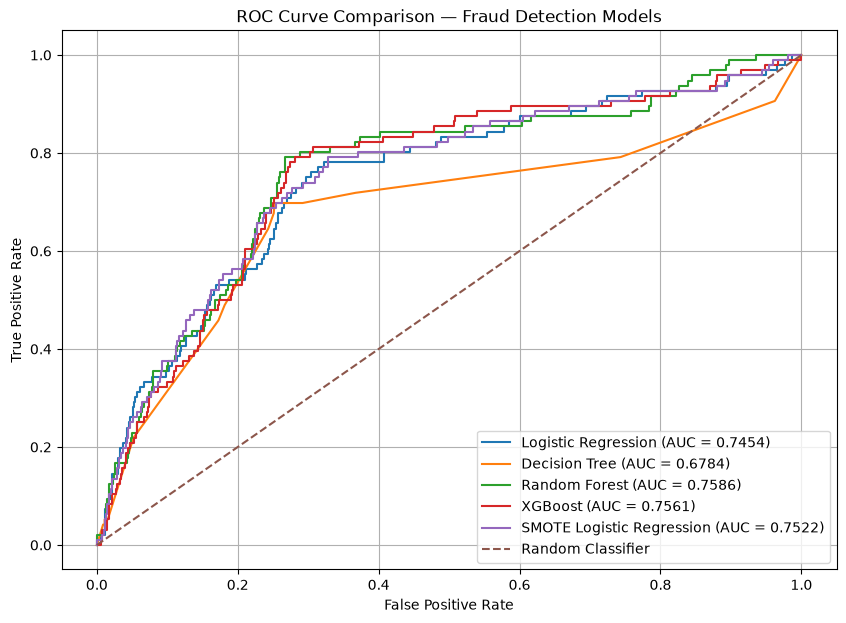

In [93]:
# Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Store model probabilities
prediction_arrays = {
    "Logistic Regression": y_proba,
    "Decision Tree": dt_y_prob,
    "Random Forest": rf_y_prob,
    "XGBoost": xgb_y_prob,
    "SMOTE Logistic Regression": smote_y_prob
}

# Create the ROC curve figure
plt.figure(figsize=(10, 7))

# Plot the ROC curve for each model
for model_name, probabilities in prediction_arrays.items():

    # Calculate false-positive rate and true-positive rate
    false_positive_rate, true_positive_rate, thresholds = roc_curve(
        y_test,
        probabilities
    )

    # Calculate ROC-AUC
    auc_score = roc_auc_score(y_test, probabilities)

    # Plot the model's ROC curve
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )

# Plot the random-classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

# Add chart labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — Fraud Detection Models")

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the chart
plt.show()

ROC curves were generated using the evaluation-set predictions from the developed models.

ROC-AUC was used to evaluate the ability of each model to distinguish between fraudulent and legitimate transactions across different classification thresholds.

The ROC analysis was considered alongside other metrics because the dataset contains a larger number of legitimate transactions than fraudulent transactions.

The ROC-AUC values from the evaluation split were different from the cross-validation mean values. Therefore, the evaluation split results were not treated as a replacement for cross-validation.



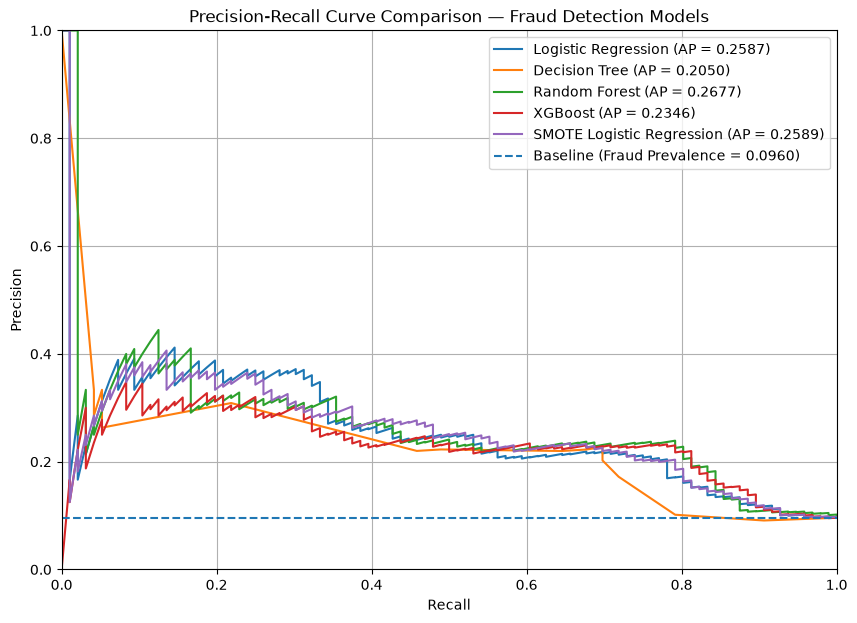

In [94]:
# Import required libraries
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Store model probabilities
prediction_arrays = {
    "Logistic Regression": y_proba,
    "Decision Tree": dt_y_prob,
    "Random Forest": rf_y_prob,
    "XGBoost": xgb_y_prob,
    "SMOTE Logistic Regression": smote_y_prob
}

# Create the Precision-Recall curve figure
plt.figure(figsize=(10, 7))

# Plot the Precision-Recall curve for each model
for model_name, probabilities in prediction_arrays.items():

    # Calculate precision and recall at different thresholds
    precision, recall, thresholds = precision_recall_curve(
        y_test,
        probabilities
    )

    # Calculate Average Precision
    average_precision = average_precision_score(
        y_test,
        probabilities
    )

    # Plot the model's Precision-Recall curve
    plt.plot(
        recall,
        precision,
        label=f"{model_name} (AP = {average_precision:.4f})"
    )

# Calculate the proportion of actual fraud cases
fraud_prevalence = y_test.mean()

# Plot the baseline representing the fraud prevalence
plt.axhline(
    y=fraud_prevalence,
    linestyle="--",
    label=f"Baseline (Fraud Prevalence = {fraud_prevalence:.4f})"
)

# Add chart labels and title
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison — Fraud Detection Models")

# Set the axis limits
plt.xlim(0, 1)
plt.ylim(0, 1)

# Add legend and grid
plt.legend()
plt.grid(True)

# Display the chart
plt.show()

## 4. Precision–Recall Curve Analysis

Precision–Recall curves were generated for the developed models.

Average Precision was used to evaluate the relationship between precision and recall across different classification thresholds.

This analysis was important because fraud detection involves an imbalanced target variable:

- Legitimate transactions: 4,518
- Fraudulent transactions: 482
- Fraudulent transaction proportion: approximately 9.64%

The Precision–Recall analysis demonstrated why fraud detection performance should not be evaluated using accuracy alone.



In [95]:
# Create a detailed error analysis dataset for Random Forest

# Copy the original test transactions using their original indices
rf_error_analysis_df = df.loc[X_test.index].copy()

# Add actual target values
rf_error_analysis_df["Actual_Fraudulent"] = y_test

# Add Random Forest predictions
rf_error_analysis_df["Predicted_Fraudulent"] = rf_y_pred

# Add Random Forest fraud probabilities
rf_error_analysis_df["Fraud_Probability"] = rf_y_prob

# Classify each prediction outcome
rf_error_analysis_df["Prediction_Type"] = "Correct"

# Identify false positives
rf_error_analysis_df.loc[
    (rf_error_analysis_df["Actual_Fraudulent"] == 0) &
    (rf_error_analysis_df["Predicted_Fraudulent"] == 1),
    "Prediction_Type"
] = "False Positive"

# Identify false negatives
rf_error_analysis_df.loc[
    (rf_error_analysis_df["Actual_Fraudulent"] == 1) &
    (rf_error_analysis_df["Predicted_Fraudulent"] == 0),
    "Prediction_Type"
] = "False Negative"

# Identify true positives
rf_error_analysis_df.loc[
    (rf_error_analysis_df["Actual_Fraudulent"] == 1) &
    (rf_error_analysis_df["Predicted_Fraudulent"] == 1),
    "Prediction_Type"
] = "True Positive"

# Identify true negatives
rf_error_analysis_df.loc[
    (rf_error_analysis_df["Actual_Fraudulent"] == 0) &
    (rf_error_analysis_df["Predicted_Fraudulent"] == 0),
    "Prediction_Type"
] = "True Negative"

# Display the count of each prediction type
print("Random Forest Prediction Type Counts:")
print(rf_error_analysis_df["Prediction_Type"].value_counts())

# Display the percentage of each prediction type
print("\nRandom Forest Prediction Type Percentages:")
print(
    rf_error_analysis_df["Prediction_Type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Random Forest Prediction Type Counts:
Prediction_Type
True Negative     673
False Positive    231
True Positive      70
False Negative     26
Name: count, dtype: int64

Random Forest Prediction Type Percentages:
Prediction_Type
True Negative     67.3
False Positive    23.1
True Positive      7.0
False Negative     2.6
Name: proportion, dtype: float64


False positives: 231 legitimate transactions were classified as fraudulent.
False negatives: 26 fraudulent transactions were classified as non-fraudulent.
True positives: 70 fraudulent transactions were detected.
True negatives: 673 legitimate transactions were correctly classified.

By this initial quantitative analysis have now confirmed.

In [96]:
# Filter false-positive transactions
false_positive_df = rf_error_analysis_df[
    rf_error_analysis_df["Prediction_Type"] == "False Positive"
].copy()

# Select relevant transaction columns for inspection
false_positive_columns = [
    "Transaction_ID",
    "Customer_ID",
    "Transaction_Date",
    "Transaction_Amount",
    "Merchant_Category",
    "Payment_Method",
    "Device_Type",
    "Location",
    "Is_International",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days",
    "Fraud_Probability",
    "Prediction_Type"
]

# Display false positives sorted by fraud probability of top 20 transactions
false_positive_df[false_positive_columns].sort_values(by="Fraud_Probability",ascending=False).head(20)

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Fraud_Probability,Prediction_Type
4482,T104482,CUST4259,21-09-2023 05:07,64.50,Utilities,PayPal,Desktop,Delhi,1,44,346.45,939,0.805011,False Positive
1151,T101151,CUST6286,21-06-2023 05:40,145.13,Travel,NetBanking,Desktop,Delhi,1,93,387.47,857,0.801590,False Positive
904,T100904,CUST7827,10-01-2024 02:46,43.77,Health,Credit Card,Desktop,Mumbai,1,183,335.46,1257,0.798912,False Positive
1317,T101317,CUST7226,12-05-2023 03:28,105.22,Entertainment,PayPal,POS,Delhi,1,60,420.04,546,0.790758,False Positive
4409,T104409,CUST4905,09-11-2023 01:23,64.73,Travel,UPI,POS,Mumbai,1,7,247.76,1113,0.781306,False Positive
3214,T103214,CUST4570,22-01-2024 01:10,20.87,Health,UPI,Desktop,Hyderabad,1,59,159.79,53,0.779936,False Positive
4993,T104993,CUST1077,09-04-2023 05:06,83.64,Electronics,NetBanking,Mobile,Delhi,1,169,191.75,959,0.775354,False Positive
1643,T101643,CUST5143,11-08-2023 01:34,78.17,Food,Debit Card,Mobile,Hyderabad,1,26,87.77,1130,0.769603,False Positive
4761,T104761,CUST3978,19-08-2023 03:46,346.79,Health,PayPal,POS,Bengaluru,1,30,405.21,680,0.758836,False Positive
4159,T104159,CUST6885,01-01-2023 05:46,66.73,Entertainment,Debit Card,Desktop,Hyderabad,1,50,421.59,79,0.758666,False Positive


In [97]:
# Analyze common patterns among false-positive transactions

# Define categorical columns for pattern analysis
categorical_columns = [
    "Merchant_Category",
    "Payment_Method",
    "Device_Type",
    "Location",
    "Is_International"
]

# Display the most frequent values in each categorical column
for column in categorical_columns:

    print(f"\nFalse Positive Analysis: {column}")

    # Count false positives by the selected column
    pattern_counts = (false_positive_df[column].value_counts().head(10))

    # Display the results
    print(pattern_counts)


False Positive Analysis: Merchant_Category
Merchant_Category
Health           38
Grocery          34
Electronics      32
Entertainment    29
Food             27
Travel           26
Fashion          23
Utilities        22
Name: count, dtype: int64

False Positive Analysis: Payment_Method
Payment_Method
NetBanking     49
Credit Card    48
PayPal         46
Debit Card     46
UPI            42
Name: count, dtype: int64

False Positive Analysis: Device_Type
Device_Type
Desktop    83
Mobile     75
POS        73
Name: count, dtype: int64

False Positive Analysis: Location
Location
Delhi        41
Kolkata      40
Mumbai       33
Hyderabad    33
Pune         31
Bengaluru    30
Chennai      23
Name: count, dtype: int64

False Positive Analysis: Is_International
Is_International
0    174
1     57
Name: count, dtype: int64


In [98]:
# Analyze false-positive rates among legitimate transactions

# Select transactions that are actually non-fraudulent
legitimate_test_df = rf_error_analysis_df[rf_error_analysis_df["Actual_Fraudulent"] == 0].copy()

# Define categorical columns for rate analysis
categorical_columns = [
    "Merchant_Category",
    "Payment_Method",
    "Device_Type",
    "Location",
    "Is_International"
]

# Calculate false-positive rates for each category
for column in categorical_columns:

    print(f"\nFalse-Positive Rate Analysis: {column}")

    # Count all legitimate transactions by category
    legitimate_counts = (legitimate_test_df[column]
        .value_counts()
        .rename("Legitimate_Transactions"))

    # Count false positives by category
    false_positive_counts = (false_positive_df[column]
        .value_counts()
        .rename("False_Positives"))

    # Combine both counts
    rate_analysis = pd.concat([legitimate_counts, false_positive_counts],axis=1).fillna(0)

    # Calculate the false-positive rate
    rate_analysis["False_Positive_Rate"] = (rate_analysis["False_Positives"]/ rate_analysis["Legitimate_Transactions"])

    # Convert the rate into a percentage
    rate_analysis["False_Positive_Rate_Percentage"] = (rate_analysis["False_Positive_Rate"] * 100).round(2)

    # Display results sorted by false-positive rate
    print(rate_analysis.sort_values(by="False_Positive_Rate",ascending=False))


False-Positive Rate Analysis: Merchant_Category
                   Legitimate_Transactions  False_Positives  \
Merchant_Category                                             
Health                                 122               38   
Grocery                                117               34   
Travel                                  94               26   
Food                                   101               27   
Electronics                            128               32   
Entertainment                          119               29   
Utilities                              103               22   
Fashion                                120               23   

                   False_Positive_Rate  False_Positive_Rate_Percentage  
Merchant_Category                                                       
Health                        0.311475                           31.15  
Grocery                       0.290598                           29.06  
Travel                      

## False-positive transactions were examined using the following attributes:

- Merchant category
- Payment method
- Device type
- Location
- International transaction status
- Transaction amount
- Fraud probability

The category-level counts were reviewed to identify patterns in legitimate transactions that were incorrectly classified as fraudulent.

However, category counts alone do not establish false-positive rates or prove that a particular category is responsible for model errors.



In [99]:
# Filter false-negative transactions
false_negative_df = rf_error_analysis_df[
    rf_error_analysis_df["Prediction_Type"] == "False Negative"].copy()

# Select relevant transaction columns for inspection
false_negative_columns = [
    "Transaction_ID",
    "Customer_ID",
    "Transaction_Date",
    "Transaction_Amount",
    "Merchant_Category",
    "Payment_Method",
    "Device_Type",
    "Location",
    "Is_International",
    "Previous_Transactions",
    "Average_Spend",
    "Account_Age_Days",
    "Fraud_Probability",
    "Prediction_Type"
]

# Display false negatives sorted by fraud probability
false_negative_df[false_negative_columns].sort_values(by="Fraud_Probability",ascending=False)

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Fraud_Probability,Prediction_Type
1351,T101351,CUST9473,29-11-2023 01:11,69.15,Grocery,PayPal,Mobile,Mumbai,0,96,49.09,723,0.499743,False Negative
94,T100094,CUST6489,28-09-2023 06:34,117.91,Utilities,Debit Card,Mobile,Bengaluru,1,106,35.44,1107,0.486110,False Negative
3297,T103297,CUST4113,12-01-2024 04:02,6.16,Electronics,Credit Card,Desktop,Pune,0,133,359.53,470,0.483000,False Negative
2985,T102985,CUST2791,14-10-2023 21:08,272.99,Entertainment,Debit Card,Mobile,Mumbai,1,70,105.47,1776,0.455788,False Negative
4405,T104405,CUST8493,28-02-2023 11:21,92.24,Health,PayPal,Desktop,Chennai,1,6,35.01,843,0.443539,False Negative
4791,T104791,CUST7565,07-08-2023 07:07,245.30,Utilities,Credit Card,Mobile,Kolkata,1,132,92.14,722,0.437965,False Negative
4642,T104642,CUST5964,10-01-2024 06:57,156.44,Electronics,NetBanking,Mobile,Mumbai,0,11,189.50,1477,0.309254,False Negative
1161,T101161,CUST5039,29-03-2023 06:05,11.04,Entertainment,Credit Card,POS,Mumbai,0,114,427.85,1117,0.275817,False Negative
1779,T101779,CUST9686,25-11-2023 22:22,147.04,Food,Debit Card,POS,Chennai,0,21,198.88,1887,0.262613,False Negative
3865,T103865,CUST2231,26-03-2023 08:11,35.07,Food,NetBanking,Mobile,Mumbai,0,164,278.69,990,0.259757,False Negative


### False Negatives
1. False-negative transactions were also reviewed using transaction attributes and predicted fraud probabilities.
2. Several false-negative transactions had predicted probabilities close to the default classification threshold of 0.50.
3. This suggests that classification threshold selection may affect the balance between detecting fraudulent transactions and generating false alerts.
4. False-negative transactions occurred across multiple merchant categories, payment methods, device types, and locations.
5. The inspected records alone were not sufficient to establish a definitive root cause for the classification errors.

## 6. Key Findings
The following findings were identified during validation and error analysis:

1. Cross-validation provided a more reliable performance estimate than relying only on a single evaluation split.
2. Random Forest and XGBoost showed comparable ranking performance.
3. Random Forest achieved the highest mean recall and F1-score in the cross-validation results.
4. The imbalanced target distribution makes precision, recall, F1-score, Average Precision, and confusion-matrix analysis important.
5. False positives represented a substantial portion of the Random Forest model's predicted fraud cases.
6. Some false negatives had predicted fraud probabilities close to the default threshold of 0.50.
7. Threshold analysis showed that the classification threshold affects the balance between precision, recall, and false-positive and false-negative outcomes.
8. The final model should be selected using both statistical performance and operational considerations.
---
## 7. Conclusion
1. Cross-validation, ROC analysis, Precision–Recall analysis, threshold analysis, confusion-matrix analysis, and detailed error analysis were completed.
2. Random Forest and XGBoost showed comparable ranking performance, with XGBoost achieving a slightly higher mean ROC-AUC.
3. Random Forest achieved the highest mean recall and F1-score in the cross-validation results and showed stable performance across the validation folds.
4. Based on the overall validation results and the fraud-detection objective, Random Forest was selected as the final model.
5. Random Forest probability scores will be used as the foundation for the subsequent risk-scoring system.
6. The classification threshold will be considered separately from the risk-scoring levels and will not be assumed to be the default 0.50 threshold.
7. The finalized Random Forest model will be used for the next stages of the project: risk scoring, alert generation, and dashboard development.

# Risk Scoring

In [100]:
# Verify that the finalized model inputs and anomaly predictions
# cover the expected number of transactions

print("X rows:", len(X))
print("y rows:", len(y))
print("Anomaly predictions:", len(anomaly_binary_predictions))
print("Test RF probabilities:", len(rf_y_prob))

X rows: 5000
y rows: 5000
Anomaly predictions: 5000
Test RF probabilities: 1000


In [101]:
# Prepare the finalized Random Forest model for full-dataset risk scoring (5,000 transactions)

from sklearn.base import clone

# Create a fresh copy of the finalized Random Forest pipeline
final_risk_model = clone(random_forest_pipeline)

# Train the model using all available labeled transactions
final_risk_model.fit(X, y)

# Generate fraud probabilities for all 5,000 transactions
full_rf_probability = final_risk_model.predict_proba(X)[:, 1]

# Verify the generated probabilities
print("Number of transactions:", len(full_rf_probability))
print("Minimum fraud probability:", full_rf_probability.min())
print("Maximum fraud probability:", full_rf_probability.max())

Number of transactions: 5000
Minimum fraud probability: 0.138875322458315
Maximum fraud probability: 0.8741094809505422


In [102]:
# Convert Random Forest fraud probabilities into a 0–100 base risk score (Create a base risk score for each transaction)

# Multiply the fraud probability by 100
base_risk_score = full_rf_probability * 100

# Display a few example scores
print("First 10 base risk scores:")
print(base_risk_score[:10])

# Display the score range
print("\nMinimum risk score:", base_risk_score.min())
print("Maximum risk score:", base_risk_score.max())

First 10 base risk scores:
[27.4017277  25.59762973 29.21809081 19.96035766 61.92239582 59.76412731
 21.00530033 21.88513151 23.34000829 24.37998218]

Minimum risk score: 13.8875322458315
Maximum risk score: 87.41094809505422


In [103]:
# Combine the base risk score with the existing anomaly signal
# No risk-score adjustment is applied yet

risk_scoring_check = pd.DataFrame({"Base_Risk_Score": base_risk_score,
                                   "Anomaly_Flag": anomaly_binary_predictions})

# Display the first 10 transactions
print(risk_scoring_check.head(10))

# Count normal and anomalous transactions
print("\nAnomaly flag counts:")
print(risk_scoring_check["Anomaly_Flag"].value_counts().sort_index())


   Base_Risk_Score  Anomaly_Flag
0        27.401728             0
1        25.597630             0
2        29.218091             0
3        19.960358             0
4        61.922396             0
5        59.764127             0
6        21.005300             0
7        21.885132             0
8        23.340008             0
9        24.379982             0

Anomaly flag counts:
Anomaly_Flag
0    4500
1     500
Name: count, dtype: int64


Anomaly_Flag = 1  → Isolation Forest identified the transaction as an anomaly
Anomaly_Flag = 0  → Isolation Forest considered it normal

In [104]:
# Create the final risk score by combining supervised and anomaly signals

# Convert the anomaly flag into a 0–100 anomaly score
anomaly_score = anomaly_binary_predictions * 100

# Combine the two signals
# Random Forest probability contributes 80%
# Isolation Forest anomaly signal contributes 20%
final_risk_score = (0.80 * base_risk_score+ 0.20 * anomaly_score)

# Keep the score within the 0–100 range
final_risk_score = np.clip(final_risk_score, 0, 100)

# Display basic statistics
print("Final Risk Score Statistics")
print("---------------------------")
print(f"Minimum: {final_risk_score.min():.2f}")
print(f"Maximum: {final_risk_score.max():.2f}")
print(f"Mean:    {final_risk_score.mean():.2f}")

Final Risk Score Statistics
---------------------------
Minimum: 11.11
Maximum: 89.93
Mean:    30.63


In [105]:
# Assign an operational risk level based on the final risk score

def assign_risk_level(score):
    # Low risk
    if score < 25: return "Low"

    # Medium risk
    elif score < 50: return "Medium"

    # High risk
    elif score < 75: return "High"

    # Critical risk
    else: return "Critical"


# Apply the risk-level rules to all transactions
risk_level = np.array([
    assign_risk_level(score)
    for score in final_risk_score
])

# Display the risk-level distribution
print("Risk Level Distribution")
print("-----------------------")
print(pd.Series(risk_level).value_counts().sort_index())

Risk Level Distribution
-----------------------
Critical     105
High         753
Low         3154
Medium       988
Name: count, dtype: int64


In [116]:
# Add the final risk-scoring results to the feature-engineered dataframe

# Add the Random Forest fraud probability
df_fe["Fraud_Probability"] = full_rf_probability

# Add the anomaly detection signal
df_fe["Anomaly_Flag"] = anomaly_binary_predictions

# Add the final 0–100 risk score
df_fe["Risk_Score"] = final_risk_score

# Add the operational risk level
df_fe["Risk_Level"] = risk_level

# Verify the new columns
print("Risk-scoring columns added successfully:")
print(df_fe[
    [
        "Transaction_ID",
        "Fraud_Probability",
        "Anomaly_Flag",
        "Risk_Score",
        "Risk_Level"
    ]
].head(10))

Risk-scoring columns added successfully:
  Transaction_ID  Fraud_Probability  Anomaly_Flag  Risk_Score Risk_Level
0        T100000           0.274017             0   21.921382        Low
1        T100001           0.255976             0   20.478104        Low
2        T100002           0.292181             0   23.374473        Low
3        T100003           0.199604             0   15.968286        Low
4        T100004           0.619224             0   49.537917     Medium
5        T100005           0.597641             0   47.811302     Medium
6        T100006           0.210053             0   16.804240        Low
7        T100007           0.218851             0   17.508105        Low
8        T100008           0.233400             0   18.672007        Low
9        T100009           0.243800             0   19.503986        Low


In [114]:
# Verify that all transactions received valid risk-scoring results

print("Total transactions:", len(df_fe))

print("\nMissing risk values:")
print(df_fe[["Fraud_Probability","Anomaly_Flag","Risk_Score","Risk_Level"]].isnull().sum())

print("\nRisk level counts:")
print(df_fe["Risk_Level"].value_counts())

Total transactions: 5000

Missing risk values:
Fraud_Probability    0
Anomaly_Flag         0
Risk_Score           0
Risk_Level           0
dtype: int64

Risk level counts:
Risk_Level
Low         3154
Medium       988
High         753
Critical     105
Name: count, dtype: int64


# Alert System

4,142 transactions → no alert
858 transactions → alert required
Alerts are triggered for High + Critical risk levels.

High → HIGH
Critical → CRITICAL
Low/Medium → no alert severity

## 9.1 Alert Logic

1. The alert mechanism uses the risk-scoring results generated by the Random Forest model and Isolation Forest anomaly detection.
2. Only transactions classified as High or Critical risk are marked as requiring an alert.
3. High-risk transactions are assigned HIGH alert severity.
4. Critical-risk transactions are assigned CRITICAL alert severity.
5. Low- and Medium-risk transactions do not generate alerts.
6. The alert mechanism uses actual transaction information from the dataset.

In [120]:
# Create an alert log containing only transactions that require investigation
# Build alert flags from the final risk score
df_fe["Alert_Required"] = df_fe["Risk_Level"].isin(["High", "Critical"])
df_fe["Alert_Severity"] = df_fe["Risk_Level"].map({
    "Critical": "CRITICAL",
    "High": "HIGH"
}).fillna("NO_ALERT")

# Create an alert log containing only transactions that require investigation
alert_log = df_fe[df_fe["Alert_Required"] == True].copy()

# Keep the important transaction and risk information for the alert log
alert_log = alert_log[
    [
        "Transaction_ID",
        "Customer_ID",
        "Transaction_Date",
        "Transaction_Amount",
        "Location",
        "Device_Type",
        "Fraud_Probability",
        "Anomaly_Flag",
        "Risk_Score",
        "Risk_Level",
        "Alert_Severity"
    ]
].copy()

# Add an operational status for investigation tracking
alert_log["Alert_Status"] = "PENDING_REVIEW"

# Display basic alert-log information
print("Alert Log Created")
print("-----------------")
print("Total alert records:", len(alert_log))
print("\nAlert severity counts:")
print(alert_log["Alert_Severity"].value_counts())

# Display the first few alert records
display(alert_log.head())

Alert Log Created
-----------------
Total alert records: 858

Alert severity counts:
Alert_Severity
HIGH        753
CRITICAL    105
Name: count, dtype: int64


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Location,Device_Type,Fraud_Probability,Anomaly_Flag,Risk_Score,Risk_Level,Alert_Severity,Alert_Status
19,T100019,CUST2634,2023-12-06 15:34:00,27.54,Hyderabad,POS,0.633492,0,50.679336,High,HIGH,PENDING_REVIEW
32,T100032,CUST3979,2023-10-11 01:37:00,5.38,Mumbai,Mobile,0.701854,0,56.148305,High,HIGH,PENDING_REVIEW
53,T100053,CUST2691,2023-11-13 01:08:00,180.17,Pune,Desktop,0.645078,0,51.606254,High,HIGH,PENDING_REVIEW
61,T100061,CUST2426,2023-01-24 00:12:00,25.32,Mumbai,Desktop,0.626354,0,50.108331,High,HIGH,PENDING_REVIEW
88,T100088,CUST1518,2024-01-24 00:05:00,174.58,Hyderabad,POS,0.694591,0,55.567259,High,HIGH,PENDING_REVIEW


In [119]:
# Create a unique alert ID for each alert record
# Build the alert log from the risk levels created earlier
alert_log = df_fe.loc[
    df_fe["Risk_Level"].isin(["High", "Critical"])
].copy()

# Assign alert severity and review status
alert_log["Alert_Severity"] = alert_log["Risk_Level"].map({
    "High": "HIGH",
    "Critical": "CRITICAL"
})
alert_log["Alert_Status"] = "PENDING_REVIEW"

# Create a unique alert ID for each alert record
alert_log["Alert_ID"] = [
    f"ALERT_{i:04d}" for i in range(1, len(alert_log) + 1)
]

# Sort alerts from highest to lowest risk score
alert_log = alert_log.sort_values(
    by="Risk_Score",
    ascending=False
).reset_index(drop=True)

# Display the prioritized alert queue
print("Prioritized Alert Queue")
print("-----------------------")
print("Total alerts:", len(alert_log))

display(
    alert_log[
        [
            "Alert_ID",
            "Transaction_ID",
            "Customer_ID",
            "Transaction_Date",
            "Transaction_Amount",
            "Fraud_Probability",
            "Anomaly_Flag",
            "Risk_Score",
            "Risk_Level",
            "Alert_Severity",
            "Alert_Status"
        ]
    ].head(10)
)

Prioritized Alert Queue
-----------------------
Total alerts: 858


,Alert_ID,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Fraud_Probability,Anomaly_Flag,Risk_Score,Risk_Level,Alert_Severity,Alert_Status
0,ALERT_0032,T100232,CUST8641,2023-06-20 00:47:00,68.81,0.874109,1,89.928758,Critical,CRITICAL,PENDING_REVIEW
1,ALERT_0475,T102893,CUST8585,2024-01-15 00:49:00,85.06,0.871022,1,89.681728,Critical,CRITICAL,PENDING_REVIEW
2,ALERT_0485,T102920,CUST1411,2023-05-10 01:20:00,31.48,0.867923,1,89.433872,Critical,CRITICAL,PENDING_REVIEW
3,ALERT_0373,T102245,CUST1814,2023-09-11 05:17:00,58.96,0.867390,1,89.391230,Critical,CRITICAL,PENDING_REVIEW
4,ALERT_0190,T101171,CUST9712,2023-02-06 03:11:00,317.85,0.858828,1,88.706216,Critical,CRITICAL,PENDING_REVIEW
5,ALERT_0652,T103868,CUST5340,2023-03-20 01:57:00,85.87,0.857533,1,88.602679,Critical,CRITICAL,PENDING_REVIEW
6,ALERT_0562,T103350,CUST9083,2023-10-02 02:56:00,19.36,0.856316,1,88.505320,Critical,CRITICAL,PENDING_REVIEW
7,ALERT_0615,T103646,CUST9150,2023-09-03 03:11:00,53.44,0.850252,1,88.020172,Critical,CRITICAL,PENDING_REVIEW
8,ALERT_0579,T103445,CUST8849,2023-07-14 03:29:00,83.87,0.849988,1,87.999007,Critical,CRITICAL,PENDING_REVIEW
9,ALERT_0418,T102607,CUST8401,2024-01-22 02:05:00,25.86,0.843674,1,87.493896,Critical,CRITICAL,PENDING_REVIEW


In [121]:
# Create a summary of the alert queue
alert_summary = (
    alert_log
    .groupby(["Risk_Level", "Alert_Severity", "Alert_Status"])
    .size()
    .reset_index(name="Alert_Count")
)

# Display the alert summary
print("Alert Summary")
print("-------------")
display(alert_summary)

Alert Summary
-------------


,Risk_Level,Alert_Severity,Alert_Status,Alert_Count
0,Critical,CRITICAL,PENDING_REVIEW,105
1,High,HIGH,PENDING_REVIEW,753


In [ ]:
# Display the highest-priority alert from the alert queue

top_alert = alert_log.iloc[0]

print("=" * 60)
print("🚨 FRAUD RISK ALERT")
print("=" * 60)

# Ensure Alert_ID exists, even if the alert-queue cell was not rerun
if "Alert_ID" not in alert_log.columns:
    alert_log = alert_log.reset_index(drop=True).copy()
    alert_log["Alert_ID"] = [
        f"ALERT_{i:04d}" for i in range(1, len(alert_log) + 1)
    ]

# Refresh the selected alert after adding Alert_ID
top_alert = alert_log.iloc[0]

print(f"Alert ID            : {top_alert['Alert_ID']}")
print(f"Transaction ID      : {top_alert['Transaction_ID']}")
print(f"Customer ID         : {top_alert['Customer_ID']}")
print(f"Transaction Amount  : {top_alert['Transaction_Amount']:.2f}")
print(f"Location            : {top_alert['Location']}")
print(f"Device Type         : {top_alert['Device_Type']}")
print(f"Fraud Probability   : {top_alert['Fraud_Probability']:.2%}")
print(f"Anomaly Flag        : {top_alert['Anomaly_Flag']}")
print(f"Risk Score          : {top_alert['Risk_Score']:.2f}/100")
print(f"Risk Level          : {top_alert['Risk_Level']}")
print(f"Alert Severity      : {top_alert['Alert_Severity']}")
print(f"Alert Status        : {top_alert['Alert_Status']}")

print("=" * 80)
print("ACTION: Review this transaction according to the fraud investigation procedure.")
print("=" * 80)

🚨 FRAUD RISK ALERT


KeyError: 'Alert_ID'

## 9.2 Alert Notification Workflow

When a transaction is identified as High or Critical risk, the alert mechanism marks the transaction as requiring investigation.

The alert workflow operates as follows:

1. The Random Forest model generates the fraud probability for the transaction.
2. Isolation Forest provides an anomaly signal.
3. These signals are combined into the final Risk Score.
4. The transaction is assigned a Risk Level: Low, Medium, High, or Critical.
5. High and Critical transactions are marked as `Alert_Required = True`.
6. An alert record is created in the alert log with the transaction and risk details.
7. The alert is assigned an Alert ID and prioritized according to its Risk Score.
8. The highest-priority alert can be displayed to the fraud investigation team for review.
9. The alert status initially remains `PENDING_REVIEW` until the transaction is investigated.

The current implementation provides an application-level alert and alert queue. It does not automatically send an email or SMS notification.

In a production environment, this alert output could be connected to an organization's notification system, such as email, SMS, a security monitoring platform, or an internal fraud-management system.

An alert indicates elevated fraud risk and does not by itself confirm that the transaction is fraudulent.

# Tableau Dashboard

In [115]:
# Export the final fraud-risk dataset for Tableau

# Save the complete feature-engineered dataset with
# fraud probability, anomaly flag, risk score, and risk level
tableau_data = df_fe.copy()

tableau_data.to_csv(
    "../data/processed/fraud_risk_tableau_data.csv",
    index=False
)

# Export the prioritized alert queue separately
alert_log.to_csv(
    "../data/processed/fraud_alert_log.csv",
    index=False
)

# Confirm the exported files
print("Tableau data exported successfully.")
print("Rows in Tableau dataset:", len(tableau_data))
print("Rows in alert log:", len(alert_log))

NameError: name 'alert_log' is not defined

In [117]:
# Prepare the clean dataset for Tableau dashboard development

tableau_dashboard_data = df_fe.copy()

# Create a readable fraud status for Tableau
tableau_dashboard_data["Fraud_Status"] = tableau_dashboard_data["Fraudulent"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

# Calculate the amount associated with confirmed fraudulent transactions
tableau_dashboard_data["Fraud_Amount"] = (
    tableau_dashboard_data["Transaction_Amount"]
    * tableau_dashboard_data["Fraudulent"]
)

# Create a high-risk indicator for dashboard KPIs
tableau_dashboard_data["High_Risk_Flag"] = (
    tableau_dashboard_data["Risk_Level"]
    .isin(["High", "Critical"])
    .astype(int)
)

# Create a month-year field for time-based dashboard analysis
tableau_dashboard_data["Transaction_Month_Year"] = (
    tableau_dashboard_data["Transaction_Date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

# Select the fields required for Tableau
tableau_dashboard_data = tableau_dashboard_data[
    [
        "Transaction_ID",
        "Customer_ID",
        "Transaction_Date",
        "Transaction_Month_Year",
        "Transaction_Amount",
        "Fraudulent",
        "Fraud_Status",
        "Fraud_Amount",
        "Merchant_Category",
        "Payment_Method",
        "Device_Type",
        "Location",
        "Is_International",
        "Previous_Transactions",
        "Average_Spend",
        "Account_Age_Days",
        "Transaction_Hour",
        "Transaction_DayOfWeek",
        "Transaction_Month",
        "Transaction_Day",
        "Is_Weekend",
        "Fraud_Probability",
        "Anomaly_Flag",
        "Risk_Score",
        "Risk_Level",
        "High_Risk_Flag",
        "Alert_Required",
        "Alert_Severity"
    ]
].copy()

# Save the clean Tableau-ready dataset
tableau_dashboard_data.to_csv(
    "../data/processed/tableau_dashboard_data.csv",
    index=False
)

# Verify the Tableau dataset
print("Tableau dashboard dataset created successfully.")
print("Rows:", len(tableau_dashboard_data))
print("Columns:", len(tableau_dashboard_data.columns))
print("\nDataset shape:", tableau_dashboard_data.shape)

display(tableau_dashboard_data.head())

KeyError: "['Alert_Required', 'Alert_Severity'] not in index"